<a href="https://colab.research.google.com/github/Uzma2147/Autonomous_Coding_Agent/blob/main/EDA_Retail_Sales_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Data Inspection & Profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('Warehouse_and_Retail_Sales.csv')



In [3]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [4]:
# 1. Dataset Shape & Overview
print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")



=== DATASET SHAPE ===
Rows: 224,015, Columns: 9


In [5]:
# 2. Data Types and Info
print("\n=== DATA TYPES & NON-NULL COUNTS ===")
df.info()


=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224015 entries, 0 to 224014
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              224015 non-null  int64  
 1   MONTH             224015 non-null  int64  
 2   SUPPLIER          223908 non-null  object 
 3   ITEM CODE         224015 non-null  object 
 4   ITEM DESCRIPTION  224015 non-null  object 
 5   ITEM TYPE         224013 non-null  object 
 6   RETAIL SALES      224012 non-null  float64
 7   RETAIL TRANSFERS  224014 non-null  float64
 8   WAREHOUSE SALES   224014 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 15.4+ MB


In [6]:
# 3. Missing Value Analysis
print("\n=== MISSING VALUES PER COLUMN ===")
print(df.isnull().sum())


=== MISSING VALUES PER COLUMN ===
YEAR                  0
MONTH                 0
SUPPLIER            107
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             2
RETAIL SALES          3
RETAIL TRANSFERS      1
WAREHOUSE SALES       1
dtype: int64


In [7]:
# 4. Duplicate Check
print("\n=== DUPLICATE ROWS ===")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")


=== DUPLICATE ROWS ===
Total Duplicate Rows: 0


In [8]:
# 5. Summary Statistics
print("\n=== NUMERICAL SUMMARY STATISTICS ===")
display(df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].describe())


=== NUMERICAL SUMMARY STATISTICS ===


,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,224012.000000,224014.000000,224014.000000
mean,6.902576,6.803578,24.456329
std,30.070472,29.500176,243.959119
min,-6.490000,-38.490000,-4996.000000
25%,0.000000,0.000000,0.000000
50%,0.320000,0.000000,1.000000
75%,3.370000,3.000000,5.000000
max,2739.000000,1990.830000,18317.000000


In [9]:
##Step 2: Data Cleaning & Decisions
# Cleaning Decisions:
# 1. Impute missing SUPPLIER & ITEM TYPE with 'Unknown'
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')
df['ITEM TYPE'] = df['ITEM TYPE'].fillna('Unknown')

In [10]:
# 2. Impute missing RETAIL SALES with 0.0
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(0.0)

In [11]:
# 3. Create a standardized DATE column from YEAR and MONTH
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')

In [12]:
# 4. Feature Engineering: Total Sales Volume
df['TOTAL SALES'] = df['RETAIL SALES'] + df['WAREHOUSE SALES']

In [13]:
# Verify Cleaning
print("Remaining Missing Values:", df.isnull().sum().sum())
print("Cleaned Dataset Ready!")

Remaining Missing Values: 3
Cleaned Dataset Ready!


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224015 entries, 0 to 224014
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   YEAR              224015 non-null  int64         
 1   MONTH             224015 non-null  int64         
 2   SUPPLIER          224015 non-null  object        
 3   ITEM CODE         224015 non-null  object        
 4   ITEM DESCRIPTION  224015 non-null  object        
 5   ITEM TYPE         224015 non-null  object        
 6   RETAIL SALES      224015 non-null  float64       
 7   RETAIL TRANSFERS  224014 non-null  float64       
 8   WAREHOUSE SALES   224014 non-null  float64       
 9   DATE              224015 non-null  datetime64[ns]
 10  TOTAL SALES       224014 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(4)
memory usage: 18.8+ MB


In [15]:
#Step 3: Required Visualizations (4 Core Charts)

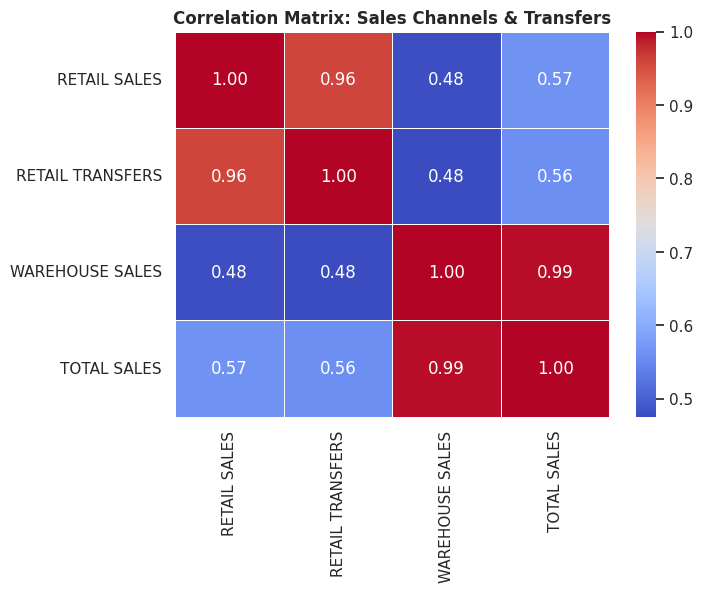

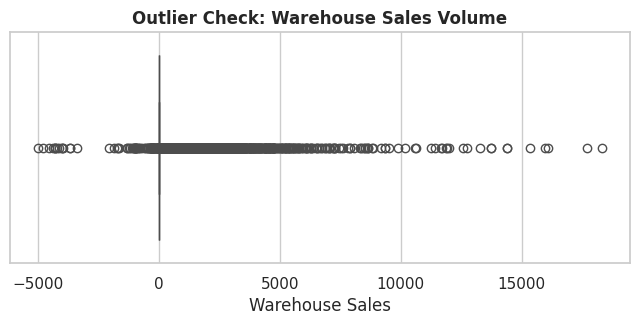

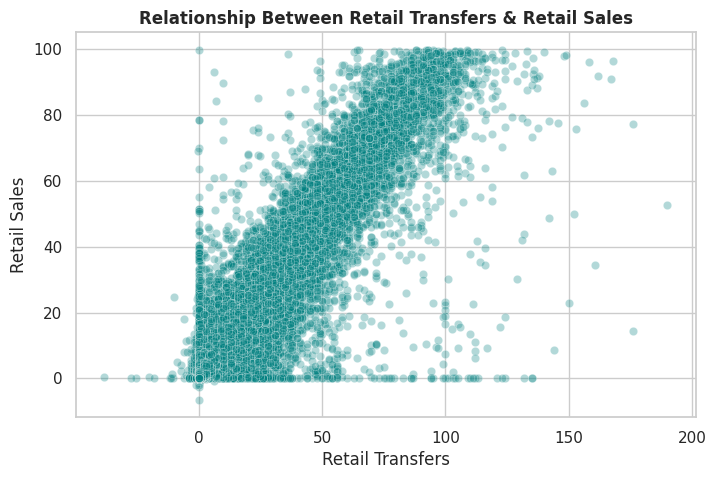

In [16]:
##Step 4 Correlation & Outliers
# 1. Correlation Heatmap
plt.figure(figsize=(7, 5))
numeric_cols = df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES', 'TOTAL SALES']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Sales Channels & Transfers", fontweight='bold')
plt.show()

# 2. Outlier Investigation: Warehouse Sales
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['WAREHOUSE SALES'], color='orange')
plt.title("Outlier Check: Warehouse Sales Volume", fontweight='bold')
plt.xlabel("Warehouse Sales")
plt.show()

# 3. Less-Obvious Chart: Retail Sales vs. Retail Transfers Relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df[df['RETAIL SALES'] < 100], x='RETAIL TRANSFERS', y='RETAIL SALES', alpha=0.3, color='teal')
plt.title("Relationship Between Retail Transfers & Retail Sales", fontweight='bold')
plt.xlabel("Retail Transfers")
plt.ylabel("Retail Sales")
plt.show()